# SVHN out-of-distribution rejection for the softmax baselines

Issue #6. Notebook 05 froze a temperature (T = 0.8628) and two abstention
thresholds on CIFAR-100 calibration data. This notebook asks the follow-up:
on SVHN test images — house-number digits, a different domain with no
CIFAR-100 class overlap — what fraction does each baseline admit, and how
well does confidence separate in-distribution from out-of-distribution?

Discipline: T and both thresholds are reused exactly as frozen in notebook
05. Nothing is fit on SVHN. SVHN labels are never used for decisions (every
SVHN image counts as should-reject); they appear only in the audit table.

Reproduce:

```bash
python3 -m jupyter nbconvert --to notebook --execute \
  notebooks/06_cifar100_svhn_ood_rejection.ipynb \
  --output /tmp/06_executed.ipynb
```

Override the run directory with `SDM_RUN_DIR` if your notebook-02 outputs
live elsewhere. The first run downloads SVHN (~300 MB) into `SDM_DATA_DIR`.



In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import ConvNeXt_Tiny_Weights, convnext_tiny
from torchvision.transforms import InterpolationMode

DATA_DIR = Path(
    os.environ.get("SDM_DATA_DIR", Path.home() / ".cache" / "sdm-vision-reliability")
).expanduser()
RUN_DIR = Path(
    os.environ.get(
        "SDM_RUN_DIR",
        Path.home()
        / ".cache"
        / "sdm-vision-reliability"
        / "runs"
        / "convnext_tiny_imagenet1k_v1"
        / "seed_42"
        / "benchmark",
    )
).expanduser()

# Frozen in notebook 05. The temperature comes from its metrics file; the
# thresholds are recomputed below with notebook 05's exact rule on the same
# calibration outputs, so they equal the frozen values bit-for-bit.
TEMPERATURE = float(
    json.loads((RUN_DIR / "metrics_05_baselines.json").read_text())["temperature"]
)
MIN_ADMITTED = 100
TARGET_ACCEPTED_ACCURACY = 0.95

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
torch.manual_seed(42)
print(f"device: {DEVICE}; frozen T = {TEMPERATURE:.4f}")


def softmax_with_temperature(logits: np.ndarray, temperature: float) -> np.ndarray:
    logits = np.asarray(logits, dtype=np.float64)
    scaled = logits / temperature
    shifted = scaled - scaled.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=1, keepdims=True)


def threshold_for_target(
    confidences: np.ndarray, correct: np.ndarray, target: float
) -> float:
    """Highest threshold whose calibration admissions clear the target accuracy."""
    order = np.argsort(-confidences)
    cumulative = np.cumsum(correct[order]) / np.arange(1, len(correct) + 1)
    ok = np.flatnonzero(cumulative >= target)
    ok = ok[ok + 1 >= MIN_ADMITTED]
    if len(ok) == 0:
        raise ValueError("95% accepted-accuracy target unattainable on calibration")
    return float(confidences[order[ok[-1]]])


cal = np.load(RUN_DIR / "calibration_outputs_full.npz")
test = np.load(RUN_DIR / "test_outputs_full.npz")
cal_logits, cal_targets = cal["logits"], cal["targets"]
test_logits, test_targets = test["logits"], test["targets"]

cal_raw = softmax_with_temperature(cal_logits, 1.0)
cal_scaled = softmax_with_temperature(cal_logits, TEMPERATURE)
test_raw = softmax_with_temperature(test_logits, 1.0)
test_scaled = softmax_with_temperature(test_logits, TEMPERATURE)
cal_conf = {"softmax": cal_raw.max(axis=1), "temp-scaled": cal_scaled.max(axis=1)}
cal_ok = {
    "softmax": cal_raw.argmax(axis=1) == cal_targets,
    "temp-scaled": cal_scaled.argmax(axis=1) == cal_targets,
}
THRESHOLDS = {
    name: threshold_for_target(cal_conf[name], cal_ok[name], TARGET_ACCEPTED_ACCURACY)
    for name in ("softmax", "temp-scaled")
}
print(f"frozen thresholds: softmax={THRESHOLDS['softmax']:.4f}, "
      f"temp-scaled={THRESHOLDS['temp-scaled']:.4f}")



device: mps; frozen T = 0.8628
frozen thresholds: softmax=0.7501, temp-scaled=0.8527


In [2]:
# Same architecture and weights as notebook 02's benchmark run.
weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
model = convnext_tiny(weights=weights)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, 100)
checkpoint = torch.load(
    RUN_DIR / "best_checkpoint.pt", map_location="cpu", weights_only=False
)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE).eval()
print(f"loaded checkpoint (best val: {checkpoint['best_validation_accuracy']:.2%})")



loaded checkpoint (best val: 88.96%)


In [3]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
eval_transform = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

svhn = datasets.SVHN(DATA_DIR, split="test", download=True, transform=eval_transform)
svhn_loader = DataLoader(svhn, batch_size=128, shuffle=False, num_workers=0)
cifar100_names = datasets.CIFAR100(DATA_DIR, train=False, download=False).classes
print(f"SVHN test images: {len(svhn)}")


@torch.inference_mode()
def collect_logits(loader) -> np.ndarray:
    chunks = []
    for images, _ in loader:
        chunks.append(model(images.to(DEVICE)).detach().to("cpu").numpy())
    return np.concatenate(chunks, axis=0)


svhn_logits = collect_logits(svhn_loader)
print(f"logits: {svhn_logits.shape}")
np.savez_compressed(
    RUN_DIR / "svhn_outputs_full.npz", logits=svhn_logits, labels=np.asarray(svhn.labels)
)



SVHN test images: 26032
logits: (26032, 100)


In [4]:
svhn_raw = softmax_with_temperature(svhn_logits, 1.0)
svhn_scaled = softmax_with_temperature(svhn_logits, TEMPERATURE)
svhn_conf = {"softmax": svhn_raw.max(axis=1), "temp-scaled": svhn_scaled.max(axis=1)}
id_conf = {"softmax": test_raw.max(axis=1), "temp-scaled": test_scaled.max(axis=1)}


def auroc(id_scores: np.ndarray, ood_scores: np.ndarray) -> float:
    scores = np.concatenate([id_scores, ood_scores])
    labels = np.concatenate([np.ones_like(id_scores), np.zeros_like(ood_scores)])
    order = np.argsort(-scores, kind="stable")
    labels = labels[order]
    tp = np.cumsum(labels)
    fp = np.cumsum(1 - labels)
    tp = np.concatenate([[0.0], tp]) / tp[-1]
    fp = np.concatenate([[0.0], fp]) / fp[-1]
    return float(np.trapz(tp, fp))  # np.trapezoid on numpy>=2.0


print(f"{'method':<12}{'admit@frozen':>13}{'AUROC':>8}"
      f"{'meanConf ID':>12}{'meanConf OOD':>13}")
for name in ("softmax", "temp-scaled"):
    admitted = svhn_conf[name] >= THRESHOLDS[name]
    print(
        f"{name:<12}{admitted.mean():>13.2%}"
        f"{auroc(id_conf[name], svhn_conf[name]):>8.4f}"
        f"{id_conf[name].mean():>12.4f}{svhn_conf[name].mean():>13.4f}"
    )

print(f"\n{'threshold':<10}{'softmax admit':>14}{'scaled admit':>13}")
for threshold in (0.5, 0.7, 0.8, 0.9):
    print(
        f"{threshold:<10.2f}{(svhn_conf['softmax'] >= threshold).mean():>14.2%}"
        f"{(svhn_conf['temp-scaled'] >= threshold).mean():>13.2%}"
    )



method       admit@frozen   AUROC meanConf ID meanConf OOD
softmax            34.95%  0.8682      0.8567       0.5899
temp-scaled        36.83%  0.8680      0.9218       0.6840

threshold  softmax admit scaled admit
0.50              61.90%       73.27%
0.70              40.98%       54.27%
0.80              27.93%       43.70%
0.90               6.96%       28.36%


saved /Users/karimmattar11/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/benchmark/figures_06_svhn.png

softmax top-5 confident SVHN admissions:
  svhn[3223] digit=3 conf=0.9675 predicted CIFAR class: cloud
  svhn[20237] digit=3 conf=0.9662 predicted CIFAR class: cloud
  svhn[24780] digit=3 conf=0.9644 predicted CIFAR class: cloud
  svhn[6832] digit=2 conf=0.9637 predicted CIFAR class: cloud
  svhn[24924] digit=2 conf=0.9605 predicted CIFAR class: cloud

temp-scaled top-5 confident SVHN admissions:
  svhn[3223] digit=3 conf=0.9905 predicted CIFAR class: cloud
  svhn[20237] digit=3 conf=0.9897 predicted CIFAR class: cloud
  svhn[24780] digit=3 conf=0.9893 predicted CIFAR class: cloud
  svhn[6832] digit=2 conf=0.9886 predicted CIFAR class: cloud
  svhn[24924] digit=2 conf=0.9879 predicted CIFAR class: cloud
saved /Users/karimmattar11/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/benchmark/metrics_06_svhn.json


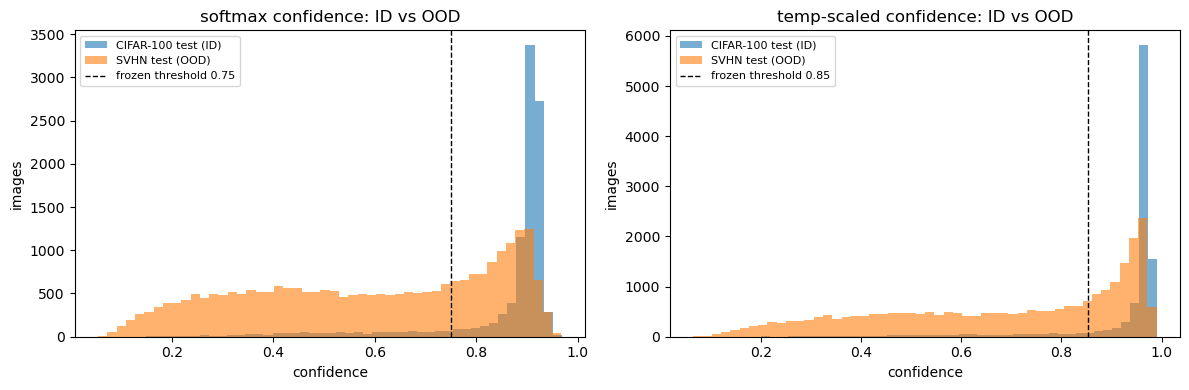

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, ("softmax", "temp-scaled")):
    ax.hist(id_conf[name], bins=50, alpha=0.6, label="CIFAR-100 test (ID)")
    ax.hist(svhn_conf[name], bins=50, alpha=0.6, label="SVHN test (OOD)")
    ax.axvline(THRESHOLDS[name], color="k", linestyle="--", linewidth=1,
               label=f"frozen threshold {THRESHOLDS[name]:.2f}")
    ax.set_title(f"{name} confidence: ID vs OOD")
    ax.set_xlabel("confidence")
    ax.set_ylabel("images")
    ax.legend(fontsize=8)
fig.tight_layout()
fig_path = RUN_DIR / "figures_06_svhn.png"
fig.savefig(fig_path, dpi=120)
print(f"saved {fig_path}")

# Audit: the most confident SVHN admissions under each method.
for name in ("softmax", "temp-scaled"):
    admitted = np.flatnonzero(svhn_conf[name] >= THRESHOLDS[name])
    top = admitted[np.argsort(-svhn_conf[name][admitted])[:5]]
    print(f"\n{name} top-5 confident SVHN admissions:")
    for idx in top:
        pred = cifar100_names[int(svhn_raw[idx].argmax())]
        print(f"  svhn[{idx}] digit={int(svhn.labels[idx])} "
              f"conf={svhn_conf[name][idx]:.4f} predicted CIFAR class: {pred}")

metrics = {
    "temperature": TEMPERATURE,
    "thresholds": THRESHOLDS,
    "fit_on": "CIFAR-100 calibration only (notebook 05); nothing fit on SVHN",
    "svhn_test_examples": int(len(svhn)),
    "metrics": {
        name: {
            "admission_rate_at_frozen_threshold": float(
                (svhn_conf[name] >= THRESHOLDS[name]).mean()
            ),
            "id_vs_ood_auroc": auroc(id_conf[name], svhn_conf[name]),
            "mean_confidence_id": float(id_conf[name].mean()),
            "mean_confidence_ood": float(svhn_conf[name].mean()),
        }
        for name in ("softmax", "temp-scaled")
    },
}
metrics_path = RUN_DIR / "metrics_06_svhn.json"
metrics_path.write_text(json.dumps(metrics, indent=2) + "\n")
print(f"saved {metrics_path}")



## Reading the results

What to look for:

- A low admission rate at the frozen thresholds means the CIFAR-100
  abstention rule carries over to a new domain instead of admitting
  everything. Compare against the ~88% CIFAR-100 test coverage in
  notebook 05: the gap between ID coverage and OOD admission is the
  usable rejection signal.
- AUROC near 1.0 means confidence alone separates the two domains; near
  0.5 means SVHN confidences look just like CIFAR-100 confidences and the
  threshold cannot tell them apart.
- If temperature scaling raises the OOD admission rate much more than the
  ID coverage, the sharper probabilities (T < 1) buy calibration on
  CIFAR-100 at the cost of louder mistakes elsewhere — worth naming in
  the SDM comparison, since SDM is supposed to stay quiet off-manifold.

